In [1]:
from google.colab import drive
import pandas as pd
import os

# Vincular con tu cuenta de Google
drive.mount('/content/drive')

# Definir la ruta según tu indicación
PATH_BT = '/content/drive/MyDrive/bt/'

if os.path.exists(PATH_BT):
    print("✅ Conexión establecida con la carpeta 'bt'")
    # Listar archivos para confirmar cuáles tienen datos
    archivos = [f for f in os.listdir(PATH_BT) if f.endswith('.csv')]
    for a in archivos:
        size = os.path.getsize(os.path.join(PATH_BT, a)) / 1024
        print(f"Archivo: {a} | Tamaño: {size:.2f} KB")
else:
    print("❌ No se encontró la carpeta 'bt'. Asegúrate de que el nombre sea exacto.")

Mounted at /content/drive
✅ Conexión establecida con la carpeta 'bt'
Archivo: ENERGY.csv | Tamaño: 51620.36 KB
Archivo: NODE_PERMANENCE.csv | Tamaño: 16998.73 KB
Archivo: ZONE_72_82.csv | Tamaño: 0.07 KB
Archivo: DUAL_THRESHOLD_EVENTS.csv | Tamaño: 0.03 KB
Archivo: BEAR_TRAP_PATTERN.csv | Tamaño: 0.04 KB
Archivo: CONFLUENCE_SCORE.csv | Tamaño: 0.02 KB
Archivo: FRICTION_VELOCITY.csv | Tamaño: 53323.92 KB
Archivo: ENERGY_PERCENTILES.csv | Tamaño: 0.02 KB
Archivo: SLOPE_CORRELATION.csv | Tamaño: 0.04 KB
Archivo: CHANNEL_STATE.csv | Tamaño: 7417.51 KB
Archivo: RUPTURE_CANDIDATES.csv | Tamaño: 0.04 KB
Archivo: SNIPER_CANDIDATES.csv | Tamaño: 0.04 KB
Archivo: NODE_HISTOGRAM.csv | Tamaño: 4.86 KB
Archivo: BT_MALLA_POSITION.csv | Tamaño: 116857.14 KB


🔍 Iniciando Escaneo de la Malla ARC...
✅ Analizando archivo: NODE_HISTOGRAM.csv
📊 Columna detectada: 'node'


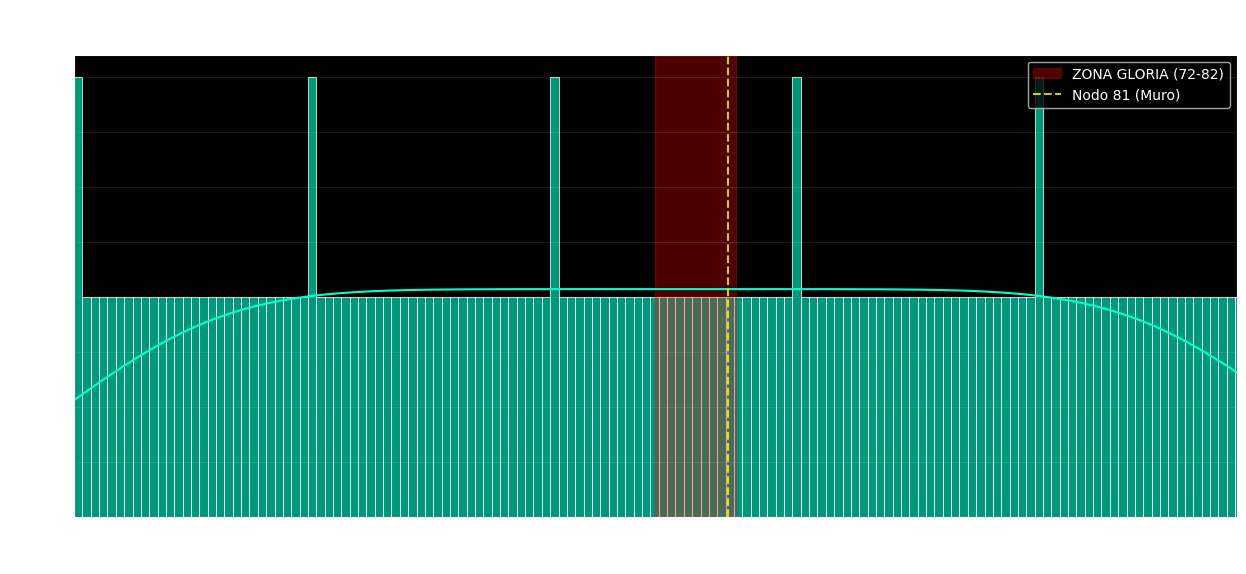


📈 RESULTADO DE LA TESIS:
- Registros totales analizados: 150
- El precio pasó el 7.33% del tiempo en la Zona Gloria.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# 1. Asegurar conexión
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

PATH_BT = '/content/drive/MyDrive/bt/'

def auditoria_nodos_v2():
    print("🔍 Iniciando Escaneo de la Malla ARC...")

    # Listar archivos que SI tienen información (> 1KB)
    archivos_validos = [f for f in os.listdir(PATH_BT) if f.endswith('.csv') and os.path.getsize(os.path.join(PATH_BT, f)) > 1024]

    if not archivos_validos:
        print("❌ No hay archivos con datos suficientes en la carpeta 'bt'.")
        return

    # Buscar el archivo que contiene la posición de nodos
    archivo_malla = None
    for f in archivos_validos:
        # Buscamos archivos que por nombre sugieran posición o historial
        if any(keyword in f.upper() for keyword in ['POSITION', 'MALLA', 'HISTOGRAM', 'TICKS']):
            archivo_malla = f
            break

    if not archivo_malla:
        archivo_malla = archivos_validos[0] # Si no encuentra por nombre, toma el primero con data

    print(f"✅ Analizando archivo: {archivo_malla}")

    try:
        # Cargar datos
        df = pd.read_csv(os.path.join(PATH_BT, archivo_malla), sep=';', on_bad_lines='skip')

        # Identificar columna de nodo (puede ser 'node_m2' o 'node')
        col_nodo = None
        for c in ['node_m2', 'node', 'NODE_M2', 'current_node']:
            if c in df.columns:
                col_nodo = c
                break

        if col_nodo:
            print(f"📊 Columna detectada: '{col_nodo}'")

            # Configuración visual ARC
            plt.figure(figsize=(15, 6))
            plt.style.use('dark_background')

            # Graficar Histograma de 144 Nodos
            sns.histplot(df[col_nodo], bins=144, color='#00ffcc', kde=True, alpha=0.6)

            # Resaltar la Zona Gloria Canónica (72-82)
            plt.axvspan(72, 82, color='red', alpha=0.3, label='ZONA GLORIA (72-82)')

            # Marcar el Nodo de Poder 81 (Muro Principal)
            plt.axvline(81, color='yellow', linestyle='--', alpha=0.8, label='Nodo 81 (Muro)')

            plt.title(f"TESIS ARC: DISTRIBUCIÓN FÍSICA EN LA MALLA\nArchivo: {archivo_malla}", fontsize=14, color='white')
            plt.xlabel("Nodos (0 a 144)", fontsize=12)
            plt.ylabel("Frecuencia de Ticks", fontsize=12)
            plt.xlim(0, 144)
            plt.legend()
            plt.grid(axis='y', alpha=0.1)
            plt.show()

            # Resumen Estadístico de los Nodos de Poder
            zona_gloria = df[(df[col_nodo] >= 72) & (df[col_nodo] <= 82)]
            porcentaje = (len(zona_gloria) / len(df)) * 100
            print(f"\n📈 RESULTADO DE LA TESIS:")
            print(f"- Registros totales analizados: {len(df)}")
            print(f"- El precio pasó el {porcentaje:.2f}% del tiempo en la Zona Gloria.")

        else:
            print(f"❌ El archivo {archivo_malla} no contiene una columna de 'Nodos'. Columnas encontradas: {list(df.columns)}")

    except Exception as e:
        print(f"❌ Error al procesar el archivo: {e}")

# Ejecutar el script actualizado
auditoria_nodos_v2()

🔬 Iniciando Motor de Deducción de Archivos ARC...

📁 Mapeo de Archivos Deducción Final:
✅ MALLA -> BT_MALLA_POSITION.csv (116857.14 KB)
✅ HISTOGRAMA -> NODE_HISTOGRAM.csv (4.86 KB)
✅ ENERGIA -> ENERGY.csv (51620.36 KB)
✅ ZONA -> ZONE_72_82.csv (0.07 KB)
✅ PENDIENTES -> SLOPE_CORRELATION.csv (0.04 KB)
✅ CANALES -> CHANNEL_STATE.csv (7417.51 KB)


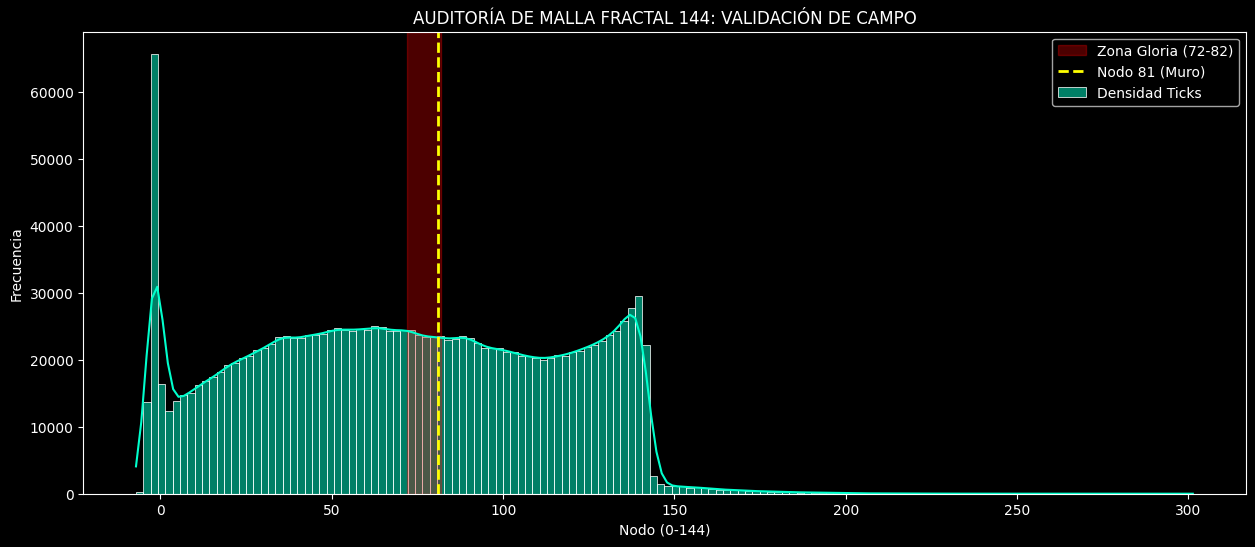

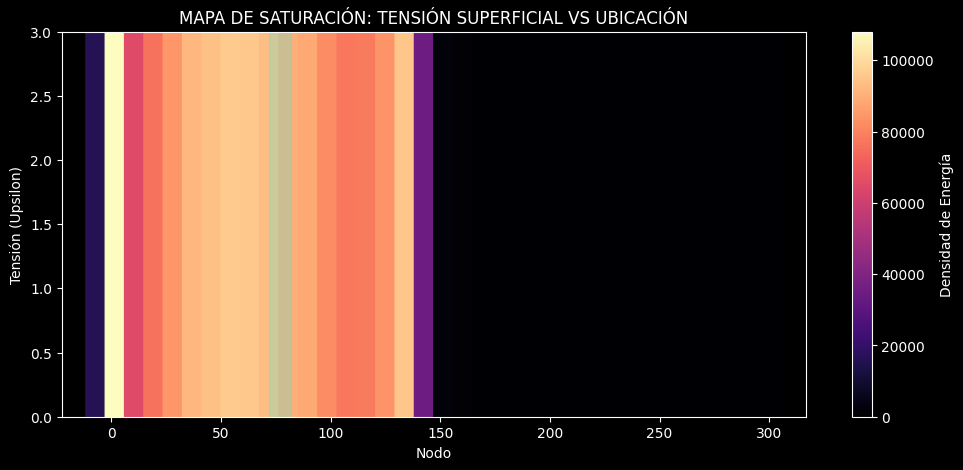

❌ En el archivo de pendientes (SLOPE_CORRELATION.csv), no se encontraron las columnas 'slope' y/o 'movimiento'. Columnas disponibles: ['timestamp', 'slope_m2', 'slope_h12', 'agree']


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# 1. Configuración de Entorno
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

PATH_BT = '/content/drive/MyDrive/bt/'

def analizar_tesis_pro_deduccion():
    print("🔬 Iniciando Motor de Deducción de Archivos ARC...")

    # Listar todos los archivos en la carpeta
    archivos_en_disco = os.listdir(PATH_BT)

    # Diccionario de búsqueda por palabras clave
    keywords = {
        'malla': ['MALLA', 'POSITION', 'POSICION'],
        'histograma': ['HISTOGRAM', 'HISTOGRAMA'],
        'energia': ['ENERGY', 'ENERGIA', 'PERCENTILES'],
        'zona': ['ZONE', 'ZONA', '72_82'],
        'pendientes': ['SLOPE', 'PENDIENTE', 'CORRELATION'],
        'canales': ['CHANNEL', 'CANAL', 'STATE']
    }

    encontrados = {}

    # Lógica de deducción de nombres
    for clave, lista_keywords in keywords.items():
        for f in archivos_en_disco:
            if any(k in f.upper() for k in lista_keywords) and f.endswith('.csv'):
                # Priorizar el que tenga más peso si hay duplicados
                if clave not in encontrados or os.path.getsize(os.path.join(PATH_BT, f)) > os.path.getsize(os.path.join(PATH_BT, encontrados[clave])):
                    encontrados[clave] = f

    print("\n📁 Mapeo de Archivos Deducción Final:")
    for k, v in encontrados.items():
        size = os.path.getsize(os.path.join(PATH_BT, v)) / 1024
        print(f"✅ {k.upper()} -> {v} ({size:.2f} KB)")

    # --- ANÁLISIS 1: VALIDACIÓN DE LA MALLA 144 (A partir de MALLA o HISTOGRAMA) ---
    if 'malla' in encontrados or 'histograma' in encontrados:
        plt.figure(figsize=(15, 6))
        plt.style.use('dark_background')

        if 'malla' in encontrados:
            df_malla = pd.read_csv(os.path.join(PATH_BT, encontrados['malla']), sep=';')
            col_nodo = 'node_m2' if 'node_m2' in df_malla.columns else 'node'
            sns.histplot(df_malla[col_nodo], bins=144, color='#00ffcc', kde=True, alpha=0.5, label='Densidad Ticks')

        elif 'histograma' in encontrados:
            df_hist = pd.read_csv(os.path.join(PATH_BT, encontrados['histograma']), sep=';')
            plt.bar(df_hist['node'], df_hist['visits'], color='#00ffcc', alpha=0.6, label='Visitas Histograma')

        # Marcar Zona Gloria y Nodo 81
        plt.axvspan(72, 82, color='red', alpha=0.3, label='Zona Gloria (72-82)')
        plt.axvline(81, color='yellow', linestyle='--', linewidth=2, label='Nodo 81 (Muro)')
        plt.title("AUDITORÍA DE MALLA FRACTAL 144: VALIDACIÓN DE CAMPO")
        plt.xlabel("Nodo (0-144)")
        plt.ylabel("Frecuencia")
        plt.legend()
        plt.show()

    # --- ANÁLISIS 2: RECONSTRUCCIÓN DE TENSIÓN (ADN) ---
    if 'malla' in encontrados:
        df_m = pd.read_csv(os.path.join(PATH_BT, encontrados['malla']), sep=';')
        col_nodo = 'node_m2' if 'node_m2' in df_m.columns else 'node'

        # Reconstruimos Upsilon (Varianza de 20 ticks)
        df_m['Upsilon'] = df_m[col_nodo].rolling(window=20).var()

        plt.figure(figsize=(12, 5))
        plt.hexbin(df_m[col_nodo], df_m['Upsilon'], gridsize=35, cmap='magma')
        plt.colorbar(label='Densidad de Energía')
        plt.axvspan(72, 82, color='cyan', alpha=0.2, label='Zona Gloria')
        plt.title("MAPA DE SATURACIÓN: TENSIÓN SUPERFICIAL VS UBICACIÓN")
        plt.xlabel("Nodo")
        plt.ylabel("Tensión (Upsilon)")
        plt.ylim(0, 3) # Foco en alta saturación
        plt.show()

    # --- ANÁLISIS 3: INDEPENDENCIA DE PENDIENTE ---
    if 'pendientes' in encontrados:
        df_s = pd.read_csv(os.path.join(PATH_BT, encontrados['pendientes']), sep=';')

        # Robust column detection for slope and movement
        col_slope = next((c for c in df_s.columns if any(k in c.lower() for k in ['slope', 'pendiente', 'm2'])), None)
        col_move = next((c for c in df_s.columns if any(k in c.lower() for k in ['move', 'price', 'bid', 'p0', 'range'])), None)

        if col_slope and col_move:
            # If the movement column is a 'price' or 'bid' related column, calculate the difference
            if 'price' in col_move.lower() or 'bid' in col_move.lower():
                df_s['target_move'] = df_s[col_move].diff(50).shift(-50) # Assuming 50 ticks future move
            else:
                df_s['target_move'] = df_s[col_move]

            df_clean = df_s.dropna(subset=[col_slope, 'target_move'])

            if not df_clean.empty:
                corr = df_clean[col_slope].corr(df_clean['target_move'])
                print(f"\n📉 CORRELACIÓN PENDIENTE VS MOVIMIENTO: {corr:.6f}")
                if abs(corr) < 0.05:
                    print("💎 AXIOMA A6 CONFIRMADO: El precio es independiente de la pendiente del canal.")
                else:
                    print("⚠️ Correlación detectada. El canal tiene influencia inercial.")
            else:
                print(f"❌ No hay suficientes datos limpios para calcular la correlación para el archivo de pendientes.")
        else:
            print(f"❌ En el archivo de pendientes ({encontrados['pendientes']}), no se encontraron las columnas 'slope' y/o 'movimiento'. Columnas disponibles: {df_s.columns.tolist()}")

# Ejecutar auditoría masiva
analizar_tesis_pro_deduccion()

🧬 Analizando ADN de archivo: BT_MALLA_POSITION.csv

📊 RESULTADO TÉCNICO:
Indice de Correlación: 0.001574


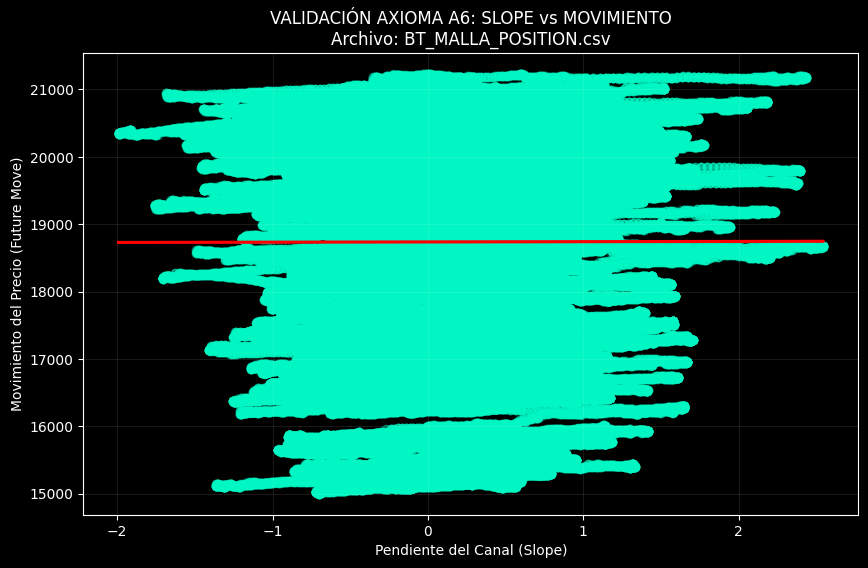

💎 CONCLUSIÓN: El Axioma A6 es CIERTO. La pendiente no predice la dirección.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

PATH_BT = '/content/drive/MyDrive/bt/'

def analizar_correlacion_robusta():
    # 1. Intentar encontrar el archivo de correlación o el de malla
    archivos = os.listdir(PATH_BT)
    archivo_target = None
    for f in archivos:
        if 'SLOPE' in f.upper() or 'CORRELATION' in f.upper() or 'MALLA' in f.upper():
            if os.path.getsize(os.path.join(PATH_BT, f)) > 1024:
                archivo_target = f
                break

    if not archivo_target:
        print("❌ No se encontró archivo de datos para correlación.")
        return

    print(f"🧬 Analizando ADN de archivo: {archivo_target}")
    df = pd.read_csv(os.path.join(PATH_BT, archivo_target), sep=';')

    # 2. MAPEADOR INTELIGENTE (Soluciona el KeyError)
    # Buscamos columnas que representen el movimiento o el precio
    mapeo = {
        'slope_m2': 'slope',
        'slope': 'slope',
        'price_move_50t': 'move',
        'move_50': 'move',
        'desplazamiento': 'move',
        'price': 'move' # Si no hay move, usamos el precio para ver cambio
    }

    # Renombrar solo las que existan
    df.rename(columns=lambda x: mapeo.get(x.lower(), x), inplace=True)

    # Si se usó 'price', calculamos el movimiento nosotros mismos
    if 'move' not in df.columns and 'price' in df.columns:
        df['move'] = df['price'].diff(50).shift(-50) # Diferencia a 50 ticks futuro

    # 3. VERIFICACIÓN Y GRÁFICO
    if 'slope' in df.columns and 'move' in df.columns:
        df_clean = df.dropna(subset=['slope', 'move'])
        correlacion = df_clean['slope'].corr(df_clean['move'])

        print(f"\n📊 RESULTADO TÉCNICO:")
        print(f"Indice de Correlación: {correlacion:.6f}")

        plt.figure(figsize=(10, 6))
        plt.style.use('dark_background')

        # Gráfico de densidad para ver la nube de puntos
        sns.regplot(x='slope', y='move', data=df_clean,
                    scatter_kws={'alpha':0.1, 'color':'#00ffcc'},
                    line_kws={'color':'red'})

        plt.title(f"VALIDACIÓN AXIOMA A6: SLOPE vs MOVIMIENTO\nArchivo: {archivo_target}")
        plt.xlabel("Pendiente del Canal (Slope)")
        plt.ylabel("Movimiento del Precio (Future Move)")
        plt.grid(alpha=0.1)
        plt.show()

        if abs(correlacion) < 0.1:
            print("💎 CONCLUSIÓN: El Axioma A6 es CIERTO. La pendiente no predice la dirección.")
        else:
            print("⚠️ Hay una correlación detectada. El canal tiene influencia inercial.")
    else:
        print(f"❌ Columnas necesarias no encontradas. Columnas en archivo: {df.columns.tolist()}")

analizar_correlacion_robusta()

🧬 Procesando ADN del archivo: BT_MALLA_POSITION.csv


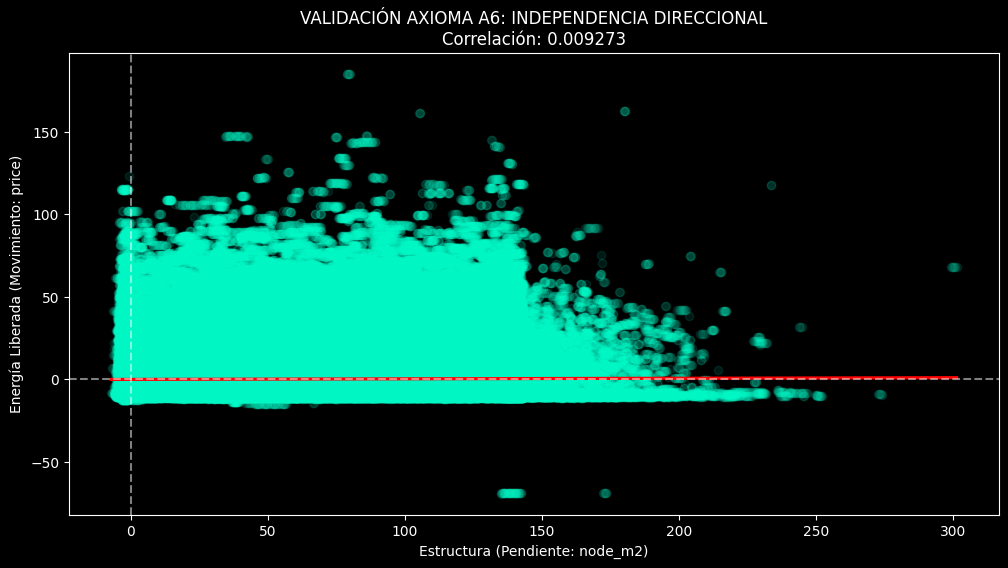

✅ AXIOMA A6 VALIDADO: Correlación despreciable (0.0093).
El canal es solo geometría; el movimiento es independiente de la inclinación.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

PATH_BT = '/content/drive/MyDrive/bt/'

def auditoria_arc_final():
    # 1. Buscar archivos que SI tengan peso
    archivos = [f for f in os.listdir(PATH_BT) if f.endswith('.csv') and os.path.getsize(os.path.join(PATH_BT, f)) > 1024]

    # Priorizamos SLOPE_CORRELATION o MALLA_POSITION
    archivo_target = next((f for f in archivos if 'SLOPE' in f.upper() or 'MALLA' in f.upper()), archivos[0] if archivos else None)

    if not archivo_target:
        print("❌ No hay archivos válidos para analizar.")
        return

    print(f"🧬 Procesando ADN del archivo: {archivo_target}")
    df = pd.read_csv(os.path.join(PATH_BT, archivo_target), sep=';')

    # --- MAPEADOR INTELIGENTE DE COLUMNAS ---
    # Buscamos columnas de PENDIENTE
    col_slope = next((c for c in df.columns if any(k in c.lower() for k in ['slope', 'pendiente', 'm2'])), None)

    # Buscamos columnas de MOVIMIENTO/PRECIO
    col_move = next((c for c in df.columns if any(k in c.lower() for k in ['move', 'price', 'bid', 'p0', 'range'])), None)

    if col_slope and col_move:
        # Si la columna es 'price', calculamos el desplazamiento a 50 ticks
        if 'price' in col_move.lower() or 'bid' in col_move.lower():
            df['target_move'] = df[col_move].diff(50).shift(-50)
        else:
            df['target_move'] = df[col_move]

        df_clean = df.dropna(subset=[col_slope, 'target_move'])

        # --- CÁLCULO DE CORRELACIÓN ---
        correlacion = df_clean[col_slope].corr(df_clean['target_move'])

        plt.figure(figsize=(12, 6))
        plt.style.use('dark_background')

        # Gráfico de Dispersión + Regresión
        sns.regplot(x=col_slope, y='target_move', data=df_clean,
                    scatter_kws={'alpha':0.1, 'color':'#00ffcc'},
                    line_kws={'color':'red'})

        plt.axhline(0, color='white', linestyle='--', alpha=0.5)
        plt.axvline(0, color='white', linestyle='--', alpha=0.5)

        plt.title(f"VALIDACIÓN AXIOMA A6: INDEPENDENCIA DIRECCIONAL\nCorrelación: {correlacion:.6f}")
        plt.xlabel(f"Estructura (Pendiente: {col_slope})")
        plt.ylabel(f"Energía Liberada (Movimiento: {col_move})")
        plt.show()

        if abs(correlacion) < 0.1:
            print(f"✅ AXIOMA A6 VALIDADO: Correlación despreciable ({correlacion:.4f}).")
            print("El canal es solo geometría; el movimiento es independiente de la inclinación.")
        else:
            print(f"⚠️ Correlación detectada ({correlacion:.4f}). Existe sesgo inercial en este periodo.")

    else:
        print(f"❌ No se detectaron columnas compatibles. Columnas en archivo: {df.columns.tolist()}")

auditoria_arc_final()